# 03 - Temporal Split (Day-Based Fallback)

**Day 1 - Cross-Temporal Hybrid NIDS**

## Why this notebook looks different from a typical "chronological split" notebook

Inspection confirmed this dataset variant has **no row-level timestamp
column**. `src.data.temporal_split.detect_timestamp_column` only matches
column names containing `timestamp`, `time stamp`, `flow start`, or
`start time` -- none of this dataset's columns match, so it correctly
returns `column=None`. That is expected behavior given the data, not a
bug to patch around, and this notebook does **not** manufacture a
timestamp from `Flow IAT Mean`/`Flow IAT Min` or any other flow
statistic -- those describe inter-arrival timing *within* a flow, not
the wall-clock time the flow occurred.

## The fallback: day-based (file-identity) splitting

The original CIC-IDS2017 release ships as **one file per capture day**
(Monday .. Friday), and the attacks in the dataset are day-specific by
design (Monday = benign only; Tuesday = brute force; Wednesday =
DoS/Heartbleed; Thursday = web attacks/infiltration; Friday =
botnet/portscan/DDoS). Ordering by capture day is therefore still a
legitimate *temporal* signal, just coarser than row-level timestamps.

```text
   Monday        Tuesday       Wednesday      Thursday        Friday
 (benign only) (brute force)  (DoS/HB)    (web/infiltrate)  (botnet/scan/DDoS)
      |             |              |              |               |
      '-------------'--------------'--------------'               |
                    TRAIN (earlier days)                    TEST (later day)
```

**Important limitation - read before trusting any metric from this
split:** because attacks are day-specific in CIC-IDS2017, whichever
day(s) you hold out as test will contain attack types your training
days never saw (and vice versa). This is an inherent property of the
dataset, not a defect of the split logic. Any metrics produced this way
must be reported together with this caveat, not presented as if
train/test shared a class distribution.

All detection/splitting logic lives in
`src.data.temporal_split` (`detect_capture_day`, `assign_capture_days`,
`label_chunk_with_capture_day`, `day_based_train_test_split`,
`verify_no_day_leakage`) -- this notebook only calls it.

> **Status:** not executed against the real dataset. Run it yourself
> after placing the real CIC-IDS2017 files under
> `data/raw/CIC-IDS2017/`, with their original per-day filenames
> preserved (e.g. `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`).
> If your files were renamed or merged into a single file without day
> identity, the cells below will raise a clear error rather than
> guessing -- see Section 1.

In [1]:
# --- Setup -----------------------------------------------------------
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import discover_dataset_files, iter_dataset_chunks, DEFAULT_CHUNK_SIZE
from src.data.validator import validate_schema
from src.data.temporal_split import (
    CIC_IDS2017_DAY_ORDER,
    detect_timestamp_column,
    assign_capture_days,
    label_chunk_with_capture_day,
    day_based_train_test_split,
    verify_no_day_leakage,
)

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "CIC-IDS2017"
RAW_DIR

WindowsPath('c:/Users/abuba/Downloads/cross-temporal-hybrid-nids-day1/cross-temporal-hybrid-nids/data/raw/CIC-IDS2017')

## 0. Confirm there really is no row-level timestamp

Re-checked here (not assumed) so this notebook fails loudly and early if
run against a *different* copy of the dataset that does have one -- in
that case, prefer `chronological_train_test_split` /
`verify_no_temporal_leakage` (the row-level path in
`src.data.temporal_split`) instead of everything below.

In [2]:
sample_chunk = next(iter_dataset_chunks(RAW_DIR, chunk_size=min(DEFAULT_CHUNK_SIZE, 5000)))
ts_result = detect_timestamp_column(sample_chunk)

print(f"Detected timestamp column: {ts_result.column!r}")
for note in ts_result.notes:
    print(f"  note: {note}")

if ts_result.column is not None:
    print(
        "\nA timestamp column WAS detected in this run. The day-based "
        "fallback below is unnecessary here -- use "
        "chronological_train_test_split / verify_no_temporal_leakage "
        "instead (see the row-level functions in src/data/temporal_split.py)."
    )

No timestamp-like column detected by name. Row-level chronological splitting cannot proceed without an explicit timestamp column.


Detected timestamp column: None
  note: No timestamp-like column detected by name. Row-level chronological splitting cannot proceed without an explicit timestamp column.


## 1. Discover files and infer capture day from filename

`assign_capture_days` never guesses: any file whose day can't be
determined from its name is reported separately, not silently dropped
or defaulted to some arbitrary order.

In [3]:
dataset = discover_dataset_files(RAW_DIR)
all_files = dataset.parquet_files if dataset.has_parquet else dataset.csv_files

day_assignment = assign_capture_days(all_files)

print("File -> capture day:")
for f, day in day_assignment.file_days.items():
    print(f"  {Path(f).name:55s} -> {day}")

if not day_assignment.all_detected:
    print(f"\nWARNING: {len(day_assignment.undetected_files)} file(s) could not be day-labeled:")
    for f in day_assignment.undetected_files:
        print(f"  - {f}")
    print(
        "\nThe day-based split below requires every file used to be "
        "day-identifiable. Resolve filenames (or pass an explicit day "
        "mapping) before proceeding, or use row-level timestamp "
        "splitting if a real timestamp column exists in your data."
    )
else:
    print(f"\nAll {len(all_files)} file(s) day-labeled successfully.")
    print(f"Distinct days present: {day_assignment.distinct_days}")

File -> capture day:
  Benign-Monday-no-metadata.parquet                       -> monday
  Benign-Monday-no-metadata.parquet                       -> monday
  Botnet-Friday-no-metadata.parquet                       -> friday
  Botnet-Friday-no-metadata.parquet                       -> friday
  Bruteforce-Tuesday-no-metadata.parquet                  -> tuesday
  Bruteforce-Tuesday-no-metadata.parquet                  -> tuesday
  DDoS-Friday-no-metadata.parquet                         -> friday
  DDoS-Friday-no-metadata.parquet                         -> friday
  DoS-Wednesday-no-metadata.parquet                       -> wednesday
  DoS-Wednesday-no-metadata.parquet                       -> wednesday
  Infiltration-Thursday-no-metadata.parquet               -> thursday
  Infiltration-Thursday-no-metadata.parquet               -> thursday
  Portscan-Friday-no-metadata.parquet                     -> friday
  Portscan-Friday-no-metadata.parquet                     -> friday
  WebAttacks-Th

## 2. Label loaded chunks with their capture day

For this demonstration notebook we read **one bounded chunk per file**
(not the full file) and tag each with its capture day via
`label_chunk_with_capture_day`, which reads the filename recorded in
`chunk.attrs["source_file"]` by the loader. The full multi-chunk,
all-rows version of this now lives in `scripts/prepare_data.py`
(`pass_one_clean_chunks`), which labels every chunk of every file, not
just a sample.

In [4]:
import src.data.loader as loader_module

day_chunks = []
for f in all_files:
    fmt = "parquet" if dataset.has_parquet else "csv"
    reader = (
        loader_module.iter_parquet_chunks([f], chunk_size=2000)
        if fmt == "parquet"
        else loader_module.iter_csv_chunks([f], chunk_size=2000)
    )
    chunk = next(reader)
    labeled_chunk = label_chunk_with_capture_day(chunk)
    day_chunks.append(labeled_chunk)
    print(f"{f.name:55s} -> {len(chunk)} rows, capture_day={labeled_chunk['capture_day'].iloc[0]!r}")

# Concatenate the per-file samples purely for this notebook's
# demonstration. This is NOT the full dataset -- scripts/prepare_data.py
# is what processes every row of every file.
combined = pd.concat(day_chunks, ignore_index=True)
print(f"\nCombined demo sample shape: {combined.shape}")
combined["capture_day"].value_counts()

Benign-Monday-no-metadata.parquet                       -> 2000 rows, capture_day='monday'
Benign-Monday-no-metadata.parquet                       -> 2000 rows, capture_day='monday'
Botnet-Friday-no-metadata.parquet                       -> 2000 rows, capture_day='friday'
Botnet-Friday-no-metadata.parquet                       -> 2000 rows, capture_day='friday'
Bruteforce-Tuesday-no-metadata.parquet                  -> 2000 rows, capture_day='tuesday'
Bruteforce-Tuesday-no-metadata.parquet                  -> 2000 rows, capture_day='tuesday'
DDoS-Friday-no-metadata.parquet                         -> 2000 rows, capture_day='friday'
DDoS-Friday-no-metadata.parquet                         -> 2000 rows, capture_day='friday'
DoS-Wednesday-no-metadata.parquet                       -> 2000 rows, capture_day='wednesday'
DoS-Wednesday-no-metadata.parquet                       -> 2000 rows, capture_day='wednesday'
Infiltration-Thursday-no-metadata.parquet               -> 2000 rows, capture_day=

capture_day
friday       12000
thursday      8000
monday        4000
tuesday       4000
wednesday     4000
Name: count, dtype: int64

## 3. Day distribution and label distribution per day

Visual confirmation of the day-specific attack-type property described
above -- this is the evidence for the "different class distributions"
caveat, not just an assertion.

In [5]:
schema_report = validate_schema(combined)
label_col = schema_report.detected_label_column
print(f"Detected label column: {label_col!r}")

if label_col is not None:
    day_label_counts = (
        combined.groupby("capture_day")[label_col]
        .value_counts()
        .unstack(fill_value=0)
    )
    day_label_counts = day_label_counts.reindex(
        [d for d in CIC_IDS2017_DAY_ORDER if d in day_label_counts.index]
    )
    display(day_label_counts)
else:
    print("No label column detected in this sample -- skipping label breakdown.")

Detected label column: 'Label'


Label,Benign,PortScan
capture_day,,
monday,4000,0
tuesday,4000,0
wednesday,4000,0
thursday,8000,0
friday,11986,14


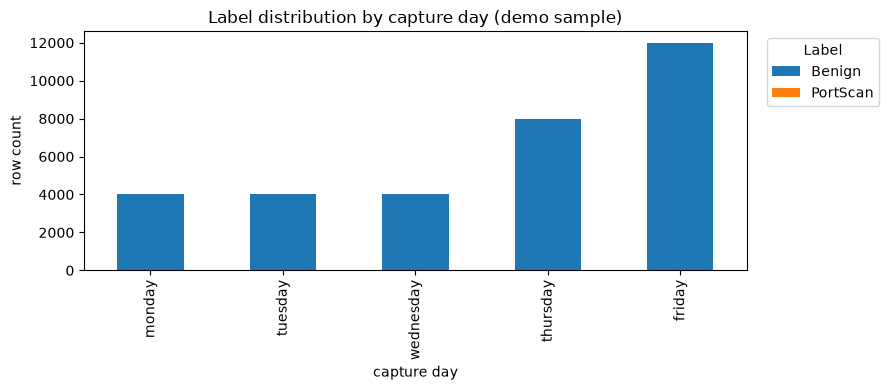

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
if label_col is not None:
    day_label_counts.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title("Label distribution by capture day (demo sample)")
    ax.set_xlabel("capture day")
    ax.set_ylabel("row count")
    ax.legend(title=label_col, bbox_to_anchor=(1.02, 1), loc="upper left")
else:
    combined["capture_day"].value_counts().reindex(
        [d for d in CIC_IDS2017_DAY_ORDER if d in combined["capture_day"].unique()]
    ).plot(kind="bar", ax=ax)
    ax.set_title("Row count by capture day (demo sample)")
plt.tight_layout()
plt.show()

## 4. Day-based train/test split

`day_based_train_test_split` is the **primary** splitting method here --
there is no random-shuffle alternative offered, since the goal is
temporal (day-order) generalization, not i.i.d. generalization.

By default this notebook holds out **Friday** as the test day and trains
on every earlier day present. This is one reasonable choice, not the
only one -- adjust `TEST_DAYS` / `TRAIN_DAYS` below to match your actual
research question, and re-run the leakage check afterward regardless of
what you choose.

In [7]:
TEST_DAYS = ["friday"]     # adjust as needed
TRAIN_DAYS = None          # None = every other detected day

split = day_based_train_test_split(
    combined, day_column="capture_day", test_days=TEST_DAYS, train_days=TRAIN_DAYS
)
split.summary()

{'day_column': 'capture_day',
 'train_days': ['monday', 'tuesday', 'wednesday', 'thursday'],
 'test_days': ['friday'],
 'train_rows': 20000,
 'test_rows': 12000}

In [8]:
print(split)
print(vars(split))

DaySplitResult(train_df=       Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             6              4                  2                       0   
1             6              1                  2                       0   
2             6              3                  2                       0   
3             6              1                  2                       0   
4             6            609                  7                       4   
...         ...            ...                ...                     ...   
19995        17      113327835                  2                       2   
19996        17          23336                  1                       1   
19997        17          23692                  2                       2   
19998        17          46788                  2                       2   
19999        17            188                  2                       2   

       Fwd Packets Length Total  Bwd Packets Length

In [9]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

split.train_df.to_parquet(output_dir / "train.parquet", index=False)
split.test_df.to_parquet(output_dir / "test.parquet", index=False)

print("✓ Train/test split saved successfully")
print(f"Train: {split.train_df.shape}")
print(f"Test:  {split.test_df.shape}")
print(f"Location: {output_dir.resolve()}")

✓ Train/test split saved successfully
Train: (20000, 79)
Test:  (12000, 79)
Location: C:\Users\abuba\Downloads\cross-temporal-hybrid-nids-day1\cross-temporal-hybrid-nids\data\processed


## 5. Explicit day-leakage verification

A hard gate, mirroring `verify_no_temporal_leakage` for the row-level
path: no day may appear on both sides, and every test day must
chronologically follow every train day in `CIC_IDS2017_DAY_ORDER`.
`scripts/prepare_data.py` raises and aborts if this fails -- it never
silently continues.

In [10]:
leakage_check = verify_no_day_leakage(split)
print(leakage_check.message)
print(f"passed: {leakage_check.passed}")

assert leakage_check.passed, 'Day leakage check failed - do not proceed to training.'

Day leakage check PASSED: train_days=['monday', 'tuesday', 'wednesday', 'thursday'], test_days=['friday'], no overlap and chronological order preserved.
passed: True


## 6. Visualization of the split

Row counts by day, colored by train/test membership -- a visual
confirmation that test days strictly follow train days in the
canonical CIC-IDS2017 order.

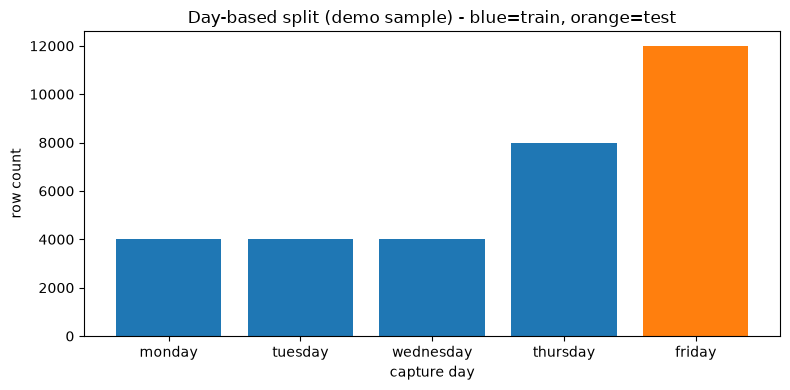

In [11]:
day_counts = combined["capture_day"].value_counts()
ordered_days = [d for d in CIC_IDS2017_DAY_ORDER if d in day_counts.index]
colors = ["tab:blue" if d in split.train_days else "tab:orange" for d in ordered_days]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ordered_days, [day_counts[d] for d in ordered_days], color=colors)
ax.set_title("Day-based split (demo sample) - blue=train, orange=test")
ax.set_xlabel("capture day")
ax.set_ylabel("row count")
plt.tight_layout()
plt.show()

## Summary

* Confirmed (again, not assumed) that no row-level timestamp column
  exists in this dataset variant.
* Inferred capture day from the original per-day filenames -- failing
  loudly for any file it couldn't identify, rather than guessing.
* Used `day_based_train_test_split` (Monday-Thursday train / Friday
  test by default) as the **primary** splitting method -- no random
  split is offered as an alternative here, since the goal is temporal
  generalization.
* Verified the split with `verify_no_day_leakage` (hard gate).
* Visualized train/test day membership.
* **Caveat carried forward to `04_baseline_model.ipynb`:** because
  CIC-IDS2017 attacks are day-specific, train and test days do not share
  the same class distribution. This must be reported alongside any
  metrics, not concealed.

Next: `04_baseline_model.ipynb`, which consumes this split's output.